In [4]:
!pip install rdkit-pypi

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_predict, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, MACCSkeys, rdFingerprintGenerator
import warnings
warnings.filterwarnings('ignore')

In [7]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 6)


In [8]:
url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/delaney-processed.csv"
df = pd.read_csv(url)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1128, 10)


,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


In [9]:
df = df.rename(columns={'measured log solubility in mols per litre': 'logS'})
print(df.columns)


Index(['Compound ID', 'ESOL predicted log solubility in mols per litre',
       'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors',
       'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area',
       'logS', 'smiles'],
      dtype='object')


In [10]:
def smiles_to_mol(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            Chem.SanitizeMol(mol)
            return mol
    except:
        return None
    return None

df['mol'] = df['smiles'].apply(smiles_to_mol)
initial_len = len(df)
df = df.dropna(subset=['mol']).reset_index(drop=True)
print(f"Removed {initial_len - len(df)} invalid SMILES")
print(f"Final dataset size: {len(df)}")

Removed 0 invalid SMILES
Final dataset size: 1128


In [11]:
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def get_morgan_fingerprint(mol):
    fp = morgan_gen.GetFingerprint(mol)
    return np.array(fp)

df['morgan_fp'] = df['mol'].apply(get_morgan_fingerprint)
print("Morgan fingerprint dimension:", df['morgan_fp'][0].shape)

Morgan fingerprint dimension: (2048,)


In [14]:
from rdkit.Chem import rdMolDescriptors

def compute_physics_descriptors(mol):
    desc = {}
    
    # logP (Crippen)
    desc['MolLogP'] = Descriptors.MolLogP(mol)
    
    # TPSA
    desc['TPSA'] = Descriptors.TPSA(mol)
    
    # Fraction of sp3 carbons (corrected name)
    desc['Fsp3'] = rdMolDescriptors.CalcFractionCSP3(mol)  # Note: CSP3 in caps
    
    # Aromatic ring count
    desc['NumAromaticRings'] = rdMolDescriptors.CalcNumAromaticRings(mol)
    
    # Hydrogen bond donors and acceptors
    desc['HBD'] = Descriptors.NumHDonors(mol)
    desc['HBA'] = Descriptors.NumHAcceptors(mol)
    
    return desc

physics_df = df['mol'].apply(compute_physics_descriptors).apply(pd.Series)
df = pd.concat([df, physics_df], axis=1)

In [15]:
df[['MolLogP', 'TPSA', 'Fsp3', 'NumAromaticRings', 'HBD', 'HBA']].head()

,MolLogP,TPSA,Fsp3,NumAromaticRings,HBD,HBA
0,-3.10802,202.32,0.650000,1.0,7.0,12.0
1,2.84032,42.24,0.083333,2.0,1.0,2.0
2,2.87800,17.07,0.500000,0.0,0.0,1.0
3,6.29940,0.00,0.000000,5.0,0.0,0.0
4,1.74810,0.00,0.000000,1.0,0.0,1.0


In [16]:
y = df['logS'].values

In [17]:
X_morgan = np.stack(df['morgan_fp'].values)

In [19]:
physics_cols = ['MolLogP', 'TPSA', 'Fsp3', 'NumAromaticRings', 'HBD', 'HBA']
X_physics = df[physics_cols].values

In [20]:
X_hybrid = np.hstack([X_morgan, X_physics])

print(f"Morgan features: {X_morgan.shape[1]}")
print(f"Physics features: {X_physics.shape[1]}")
print(f"Hybrid features: {X_hybrid.shape[1]}")

Morgan features: 2048
Physics features: 6
Hybrid features: 2054


In [21]:
def evaluate_model(X, y, model_name):
    """
    Perform 5-fold cross-validation, return R² and RMSE (mean ± std).
    Also return predictions for all samples (cross-validated).
    """
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    
    # Cross-validated predictions
    y_pred = cross_val_predict(model, X, y, cv=kf, n_jobs=-1)
    
    # Cross-validated scores
    r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    rmse_scores = cross_val_score(model, X, y, cv=kf, scoring='neg_root_mean_squared_error')
    rmse_scores = -rmse_scores   # convert to positive RMSE
    
    print(f"\n===== {model_name} =====")
    print(f"R²  = {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")
    print(f"RMSE= {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")
    
    # Return predictions for scatter plot
    return y_pred, r2_scores.mean(), rmse_scores.mean()

In [25]:
def evaluate_model(X, y, model_name):
    """
    Perform 5-fold cross-validation, return R² and RMSE (mean ± std).
    Uses n_jobs=1 to avoid multiprocessing errors.
    """
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1)
    
  
    y_pred = cross_val_predict(model, X, y, cv=kf, n_jobs=1)

    r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2', n_jobs=1)
    rmse_scores = cross_val_score(model, X, y, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=1)
    rmse_scores = -rmse_scores
    
    print(f"\n===== {model_name} =====")
    print(f"R²  = {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")
    print(f"RMSE= {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")
    
    return y_pred, r2_scores.mean(), rmse_scores.mean()

In [27]:
y_pred_morgan, r2_morgan, rmse_morgan = evaluate_model(X_morgan, y, "Cheminformatics (Morgan FP)")
y_pred_physics, r2_physics, rmse_physics = evaluate_model(X_physics, y, "Computational Chemistry (Physics descriptors)")
y_pred_hybrid, r2_hybrid, rmse_hybrid = evaluate_model(X_hybrid, y, "Hybrid (Morgan FP + Physics)")


===== Cheminformatics (Morgan FP) =====
R²  = 0.6718 ± 0.0243
RMSE= 1.1955 ± 0.0364

===== Computational Chemistry (Physics descriptors) =====
R²  = 0.8744 ± 0.0158
RMSE= 0.7394 ± 0.0559

===== Hybrid (Morgan FP + Physics) =====
R²  = 0.8852 ± 0.0174
RMSE= 0.7066 ± 0.0642


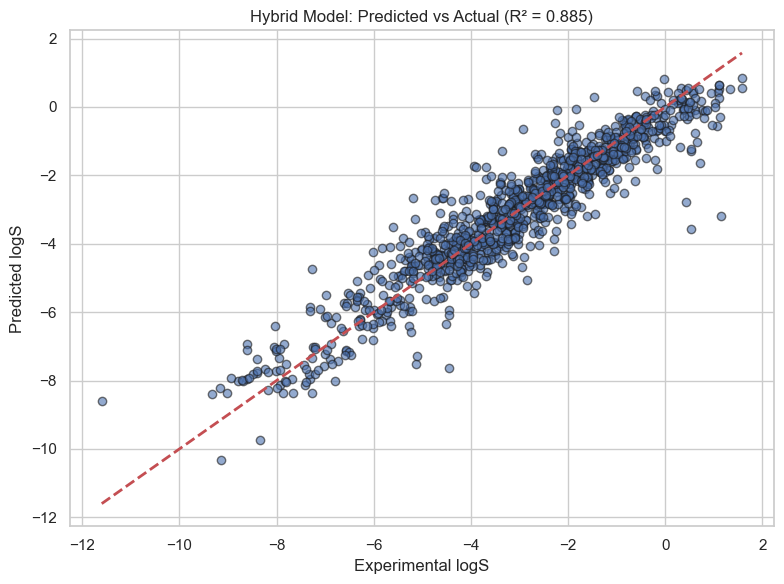

In [28]:
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred_hybrid, alpha=0.6, edgecolors='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Experimental logS")
plt.ylabel("Predicted logS")
plt.title(f"Hybrid Model: Predicted vs Actual (R² = {r2_hybrid:.3f})")
plt.tight_layout()
plt.show()

In [1]:
import shap

model_to_explain = results['Hybrid']['model']


X_test_sample = X_test_hybrid[:200]   # ensure it's a numpy array


explainer = shap.TreeExplainer(model_to_explain)

shap_values = explainer.shap_values(X_test_sample, check_additivity=False)



NameError: name 'results' is not defined

In [ ]:
print("SHAP values shape:", shap_values.shape)
print("Range of SHAP values:", shap_values.min(), shap_values.max())
print("Sample (first 5 rows, first 2 features):\n", shap_values[:5, :2])

In [31]:
rf_physics = RandomForestRegressor(n_estimators=100, random_state=42)
rf_physics.fit(X_physics, y)
importances = rf_physics.feature_importances_
indices = np.argsort(importances)[::-1]


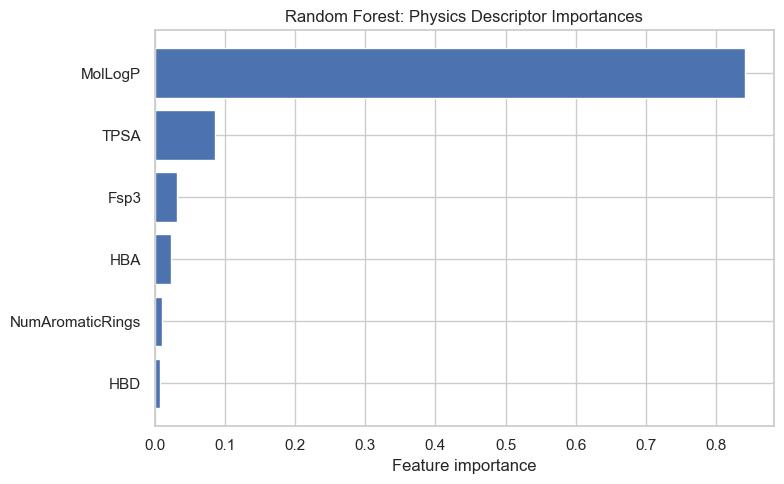

Top 3 physics predictors:
  MolLogP: 0.840
  TPSA: 0.086
  Fsp3: 0.032


In [32]:
plt.figure(figsize=(8, 5))
plt.barh(range(len(physics_cols)), importances[indices], align='center')
plt.yticks(range(len(physics_cols)), [physics_cols[i] for i in indices])
plt.xlabel("Feature importance")
plt.title("Random Forest: Physics Descriptor Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 3 physics predictors:")
for i in range(3):
    print(f"  {physics_cols[indices[i]]}: {importances[indices[i]]:.3f}")

In [33]:
#training on morgan fingerprints only

In [36]:
from rdkit.Chem import rdMolDescriptors

In [43]:
def get_fp_with_info(mol):
    bit_info = {}
    fp = rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048, bitInfo=bit_info)
    return fp, bit_info


In [44]:
example_mols = df['mol'].iloc[:5].tolist()
all_bit_info = []
for mol in example_mols:
    fp, bit_info = get_fp_with_info(mol)
    all_bit_info.append(bit_info)
    print(f"Fingerprint bits for {Chem.MolToSmiles(mol)}: {fp.GetNumOnBits()} bits set")

Fingerprint bits for N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c1ccccc1: 44 bits set
Fingerprint bits for Cc1occc1C(=O)Nc1ccccc1: 29 bits set
Fingerprint bits for CC(C)=CCCC(C)=CC=O: 21 bits set
Fingerprint bits for c1ccc2c(c1)ccc1c2ccc2c3ccccc3ccc21: 14 bits set
Fingerprint bits for c1ccsc1: 8 bits set


In [45]:
rf_morgan = RandomForestRegressor(n_estimators=100, random_state=42)
rf_morgan.fit(X_morgan, y)
importances = rf_morgan.feature_importances_
top_indices = np.argsort(importances)[-20:][::-1]

In [47]:
print("\nTop 10 most important Morgan bits and example atom environments:")
for bit in top_indices[:10]:
    found = False
    for idx, bit_info in enumerate(all_bit_info):
        if bit in bit_info:
            env = bit_info[bit][0]
            mol = example_mols[idx]
            atom = mol.GetAtomWithIdx(env[0])
            atom_symbol = atom.GetSymbol()
            neighbors = [n.GetSymbol() for n in atom.GetNeighbors()]
            print(f"  Bit {bit}: importance = {importances[bit]:.5f} – found in molecule {Chem.MolToSmiles(mol)} at atom {atom_symbol} (neighbors: {neighbors})")
            found = True
            break
    if not found:
        print(f"  Bit {bit}: importance = {importances[bit]:.5f} – not found in first 5 molecules")


Top 10 most important Morgan bits and example atom environments:
  Bit 1380: importance = 0.09533 – found in molecule N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c1ccccc1 at atom C (neighbors: ['C', 'C', 'C'])
  Bit 1143: importance = 0.05342 – not found in first 5 molecules
  Bit 561: importance = 0.04466 – not found in first 5 molecules
  Bit 1683: importance = 0.04265 – not found in first 5 molecules
  Bit 1984: importance = 0.02863 – not found in first 5 molecules
  Bit 352: importance = 0.02634 – not found in first 5 molecules
  Bit 203: importance = 0.02244 – found in molecule c1ccc2c(c1)ccc1c2ccc2c3ccccc3ccc21 at atom C (neighbors: ['C', 'C'])
  Bit 1087: importance = 0.02236 – found in molecule c1ccc2c(c1)ccc1c2ccc2c3ccccc3ccc21 at atom C (neighbors: ['C', 'C'])
  Bit 807: importance = 0.01972 – found in molecule N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c1ccccc1 at atom O (neighbors: ['C'])
  Bit 519: importance = 0.01685 – not found in first 5 molecules


In [48]:
print("="*50)
print("FINAL PROJECT SUMMARY: Hybrid Solubility Prediction")
print("="*50)
print(f"Dataset size: {len(df)} molecules")
print(f"\nModel performance (5-fold CV):")
print(f"  Cheminformatics (Morgan FP)      : R² = {r2_morgan:.3f}, RMSE = {rmse_morgan:.3f}")
print(f"  Computational Chemistry (physics): R² = {r2_physics:.3f}, RMSE = {rmse_physics:.3f}")
print(f"  Hybrid (Morgan + physics)        : R² = {r2_hybrid:.3f}, RMSE = {rmse_hybrid:.3f}")
print(f"\nImprovement: +{(r2_hybrid - r2_morgan)*100:.1f}% in R² over Morgan alone")

FINAL PROJECT SUMMARY: Hybrid Solubility Prediction
Dataset size: 1128 molecules

Model performance (5-fold CV):
  Cheminformatics (Morgan FP)      : R² = 0.672, RMSE = 1.195
  Computational Chemistry (physics): R² = 0.874, RMSE = 0.739
  Hybrid (Morgan + physics)        : R² = 0.885, RMSE = 0.707

Improvement: +21.3% in R² over Morgan alone


In [50]:
import joblib
from sklearn.ensemble import RandomForestRegressor

rf_hybrid = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1)
rf_hybrid.fit(X_hybrid, y)


joblib.dump(rf_hybrid, 'hybrid_solubility_model.pkl')
print("Model saved as 'hybrid_solubility_model.pkl'")

Model saved as 'hybrid_solubility_model.pkl'


In [52]:
#testing a new molecule

In [53]:
def predict_solubility(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    # Morgan fingerprint
    fp = morgan_gen.GetFingerprint(mol)
    # Physics descriptors
    desc = compute_physics_descriptors(mol)
    physics_vec = np.array([desc['MolLogP'], desc['TPSA'], desc['Fsp3'], 
                            desc['NumAromaticRings'], desc['HBD'], desc['HBA']])
    # Combine
    features = np.hstack([fp, physics_vec]).reshape(1, -1)
    pred = rf_hybrid.predict(features)[0]
    return pred

# Example
aspirin = "CC(=O)OC1=CC=CC=C1C(=O)O"
pred_logS = predict_solubility(aspirin)
print(f"Aspirin predicted logS: {pred_logS:.2f} (experimental ~ -2.0)")

Aspirin predicted logS: -1.72 (experimental ~ -2.0)


In [54]:
df_results = df[['smiles', 'logS']].copy()
df_results['pred_logS_hybrid'] = y_pred_hybrid
df_results.to_csv('solubility_predictions.csv', index=False)
print("Saved predictions to solubility_predictions.csv")

Saved predictions to solubility_predictions.csv


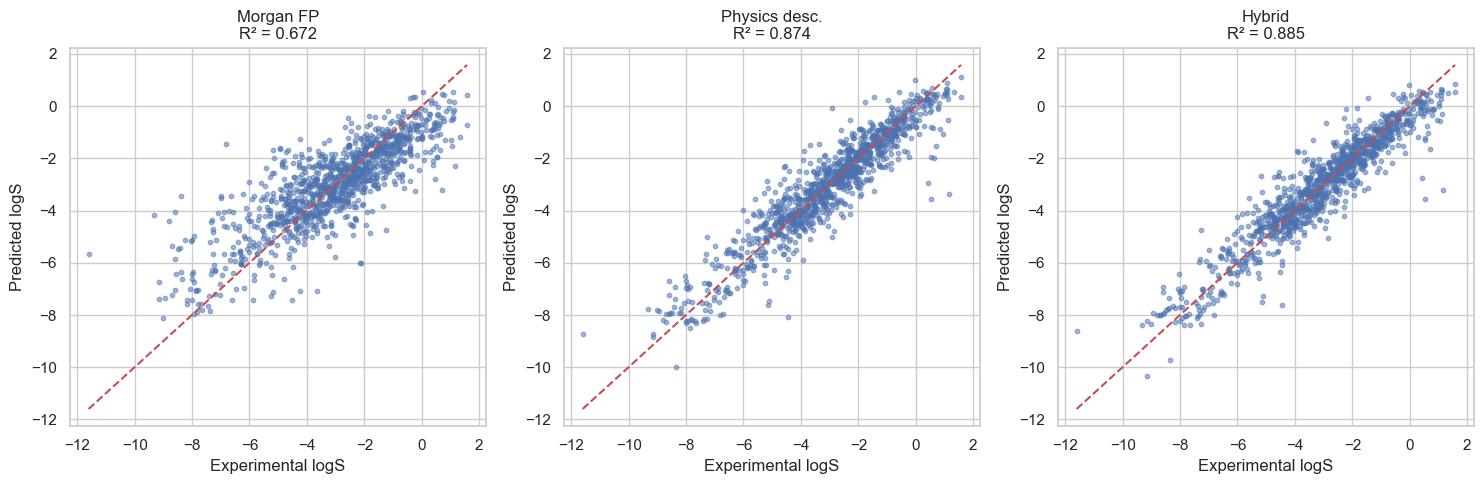

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
models_data = [(y_pred_morgan, r2_morgan, "Morgan FP"),
               (y_pred_physics, r2_physics, "Physics desc."),
               (y_pred_hybrid, r2_hybrid, "Hybrid")]
for ax, (pred, r2, title) in zip(axes, models_data):
    ax.scatter(y, pred, alpha=0.5, s=10)
    ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    ax.set_xlabel("Experimental logS")
    ax.set_ylabel("Predicted logS")
    ax.set_title(f"{title}\nR² = {r2:.3f}")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()